In [69]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) 

df = pd.read_csv('data/ecommerce_sales_analysis.csv')

In [70]:
# Data Understanding
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000, 18)


,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257


In [71]:
df.columns

Index(['product_id', 'product_name', 'category', 'price', 'review_score',
       'review_count', 'sales_month_1', 'sales_month_2', 'sales_month_3',
       'sales_month_4', 'sales_month_5', 'sales_month_6', 'sales_month_7',
       'sales_month_8', 'sales_month_9', 'sales_month_10', 'sales_month_11',
       'sales_month_12'],
      dtype='object')

In [72]:
df.dtypes

product_id          int64
product_name       object
category           object
price             float64
review_score      float64
review_count        int64
sales_month_1       int64
sales_month_2       int64
sales_month_3       int64
sales_month_4       int64
sales_month_5       int64
sales_month_6       int64
sales_month_7       int64
sales_month_8       int64
sales_month_9       int64
sales_month_10      int64
sales_month_11      int64
sales_month_12      int64
dtype: object

In [73]:
df.describe

<bound method NDFrame.describe of      product_id  product_name        category   price  review_score  \
0             1     Product_1        Clothing  190.40           1.7   
1             2     Product_2  Home & Kitchen  475.60           3.2   
2             3     Product_3            Toys  367.34           4.5   
3             4     Product_4            Toys  301.34           3.9   
4             5     Product_5           Books   82.23           4.2   
..          ...           ...             ...     ...           ...   
995         996   Product_996  Home & Kitchen   50.33           3.6   
996         997   Product_997  Home & Kitchen  459.07           4.8   
997         998   Product_998          Sports   72.73           1.3   
998         999   Product_999          Sports  475.37           1.2   
999        1000  Product_1000            Toys  225.77           2.1   

     review_count  sales_month_1  sales_month_2  sales_month_3  sales_month_4  \
0             220            479

In [74]:
#2 Data Preparation
df.head()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257


In [75]:
df = df[[
    'product_id',
    'product_name',
    'category',
    'price',
    'review_score',
    'review_count',
    'sales_month_1', 'sales_month_2', 'sales_month_3', 'sales_month_4',
    'sales_month_5', 'sales_month_6', 'sales_month_7', 'sales_month_8',
    'sales_month_9', 'sales_month_10', 'sales_month_11', 'sales_month_12'
]].copy()

In [76]:
df.dtypes

product_id          int64
product_name       object
category           object
price             float64
review_score      float64
review_count        int64
sales_month_1       int64
sales_month_2       int64
sales_month_3       int64
sales_month_4       int64
sales_month_5       int64
sales_month_6       int64
sales_month_7       int64
sales_month_8       int64
sales_month_9       int64
sales_month_10      int64
sales_month_11      int64
sales_month_12      int64
dtype: object

In [77]:
#renaming columns

rename_dict = {}

for i in range(1, 13):
    rename_dict[f'sales_month_{i}'] = f'Sales_Month_{i}'
    
rename_dict.update({
    'product_id': 'Product_ID',
    'product_name': 'Product_Name',
    'category': 'Category',
    'price': 'Price',
    'review_score': 'Review_Score',
    'review_count': 'Review_Count'
})

df = df.rename(columns=rename_dict)

In [78]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Price', 'Review_Score',
       'Review_Count', 'Sales_Month_1', 'Sales_Month_2', 'Sales_Month_3',
       'Sales_Month_4', 'Sales_Month_5', 'Sales_Month_6', 'Sales_Month_7',
       'Sales_Month_8', 'Sales_Month_9', 'Sales_Month_10', 'Sales_Month_11',
       'Sales_Month_12'],
      dtype='object')

In [79]:
#finding null/missing values
df.isna().sum()

Product_ID        0
Product_Name      0
Category          0
Price             0
Review_Score      0
Review_Count      0
Sales_Month_1     0
Sales_Month_2     0
Sales_Month_3     0
Sales_Month_4     0
Sales_Month_5     0
Sales_Month_6     0
Sales_Month_7     0
Sales_Month_8     0
Sales_Month_9     0
Sales_Month_10    0
Sales_Month_11    0
Sales_Month_12    0
dtype: int64

In [80]:
#finding and eliminating duplicate values
df.loc[df.duplicated(subset=['Product_Name', 'Category'])].sum()

Product_ID          0
Product_Name        0
Category            0
Price             0.0
Review_Score      0.0
Review_Count        0
Sales_Month_1       0
Sales_Month_2       0
Sales_Month_3       0
Sales_Month_4       0
Sales_Month_5       0
Sales_Month_6       0
Sales_Month_7       0
Sales_Month_8       0
Sales_Month_9       0
Sales_Month_10      0
Sales_Month_11      0
Sales_Month_12      0
dtype: object

In [81]:
df.reset_index(drop=True)

,Product_ID,Product_Name,Category,Price,Review_Score,Review_Count,Sales_Month_1,Sales_Month_2,Sales_Month_3,Sales_Month_4,Sales_Month_5,Sales_Month_6,Sales_Month_7,Sales_Month_8,Sales_Month_9,Sales_Month_10,Sales_Month_11,Sales_Month_12
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Product_996,Home & Kitchen,50.33,3.6,494,488,359,137,787,678,970,282,155,57,575,634,393
996,997,Product_997,Home & Kitchen,459.07,4.8,701,18,906,129,78,19,110,403,683,104,858,729,474
997,998,Product_998,Sports,72.73,1.3,287,725,109,193,657,215,337,664,476,265,344,888,654
998,999,Product_999,Sports,475.37,1.2,720,196,191,315,622,854,122,65,938,521,268,60,394


Text(0, 0.5, 'Count')

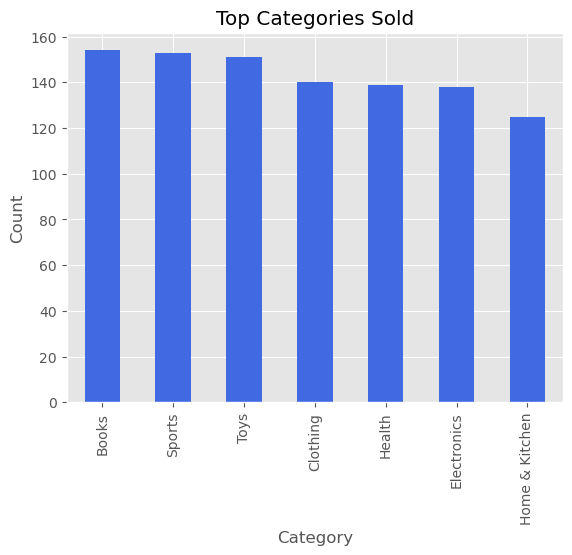

In [82]:
# 3 Feature Understanding

#analyzing product categories
plt1 = df['Category'].value_counts().head(10).plot(kind='bar', title='Top Categories Sold', color='royalblue')
plt1.set_xlabel('Category')
plt1.set_ylabel('Count')

Text(0, 0.5, 'Count')

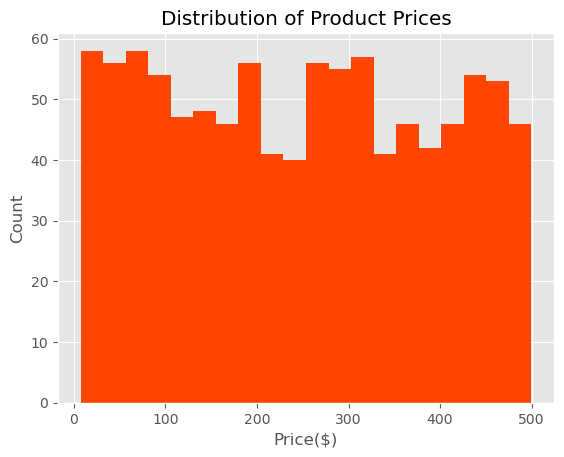

In [83]:
#distribution of product prices
plt2 = df['Price'].plot(kind='hist', 
                 bins=20, 
                 title='Distribution of Product Prices',
                 color = 'orangered')
plt2.set_xlabel('Price($)')
plt2.set_ylabel('Count')


C:\Users\zaize\AppData\Local\Temp\ipykernel_13012\3964010703.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt3.figure.show()


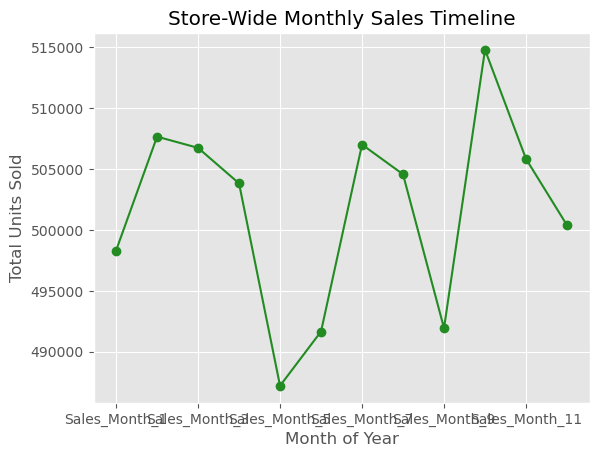

In [84]:
#store-wide monthly transactions timeline
sales_columns = [f'Sales_Month_{i}' for i in range(1, 13)]
df1 = df[sales_columns].sum()

plt3 = df1.plot(kind='line', marker='o', title='Store-Wide Monthly Sales Timeline', color='forestgreen')
plt3.set_xlabel('Month of Year')
plt3.set_ylabel('Total Units Sold')
plt3.figure.show()

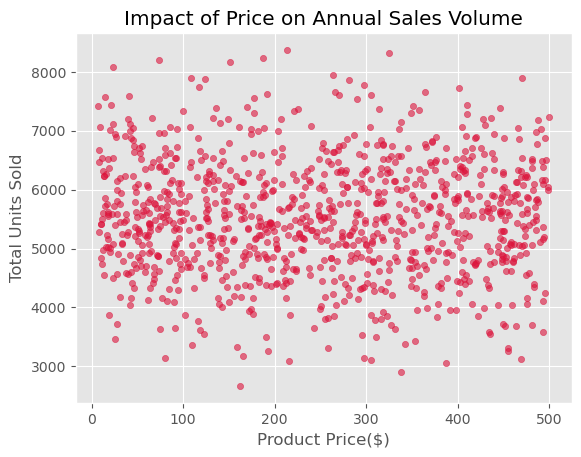

In [85]:
#analyzing impact of pricing on sales
sales_columns = [f'Sales_Month_{i}' for i in range(1, 12)]
df['Total_Sales_Year'] = df[sales_columns].sum(axis=1)

plt5 = df.plot(kind='scatter',
               x='Price',
               y='Total_Sales_Year',
               title = 'Impact of Price on Annual Sales Volume',
               color = 'crimson',
               alpha=0.6
               )
plt5.set_xlabel('Product Price($)')
plt5.set_ylabel('Total Units Sold')
plt.show()

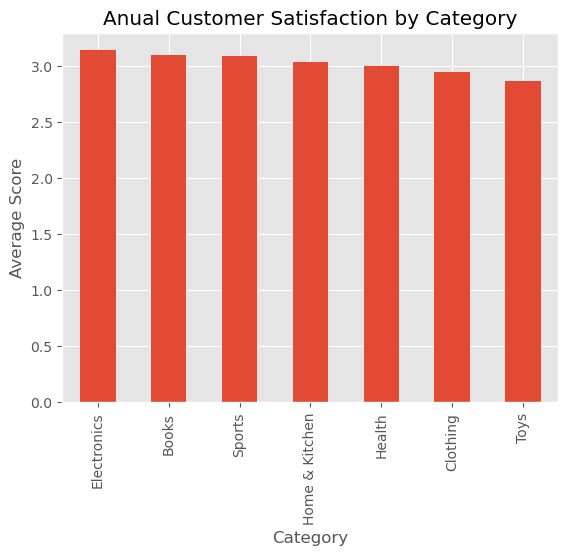

In [86]:
#evaluating customer satisfaction
catg_satf = (df.groupby('Category')['Review_Score'].mean().sort_values(ascending=False))

plt6 = catg_satf.plot(kind='bar',title='Anual Customer Satisfaction by Category')
plt6.set_xlabel('Category')
plt6.set_ylabel('Average Score')
plt.show()

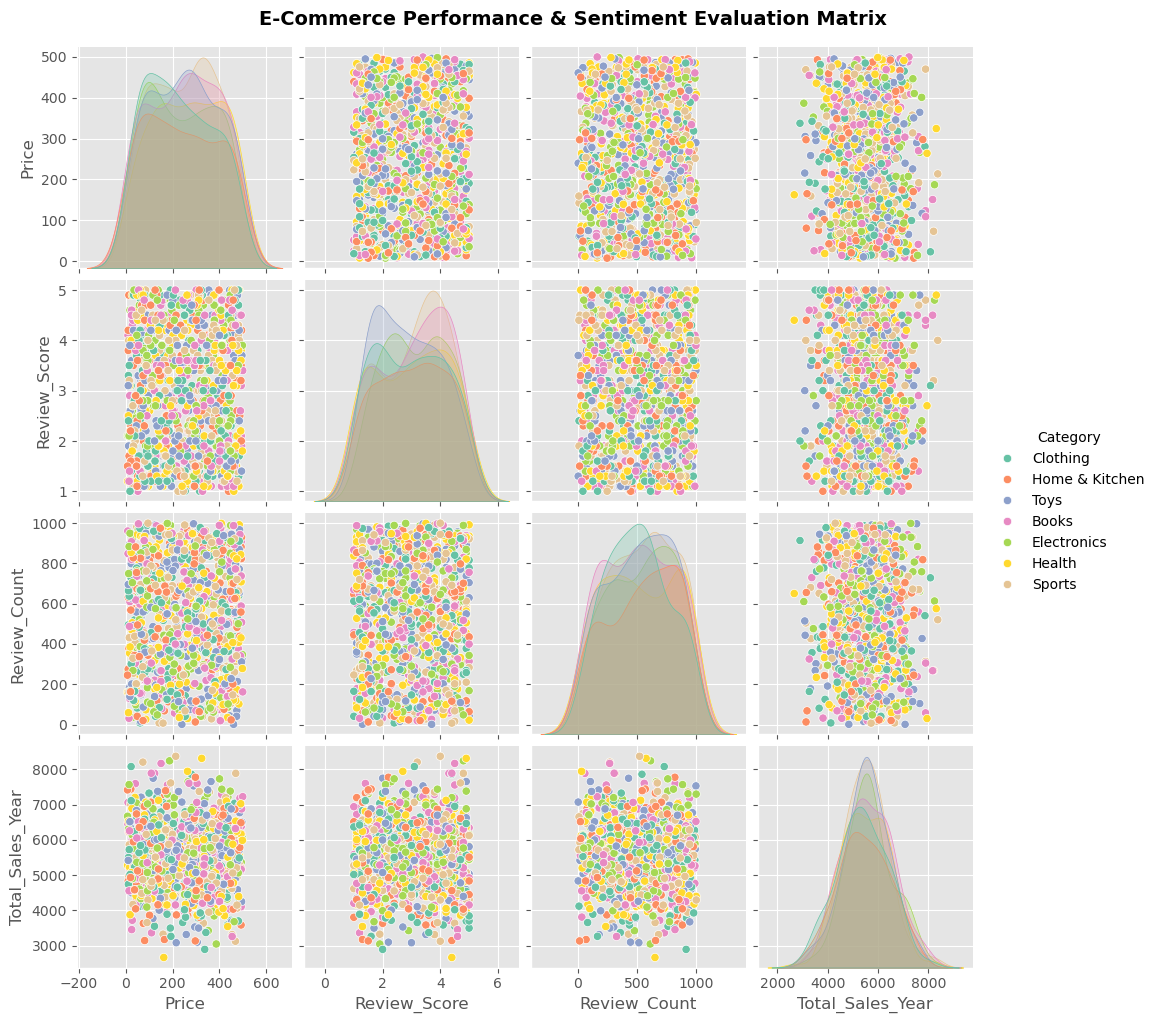

In [87]:
numerical_features = ['Price', 'Review_Score', 'Review_Count', 'Total_Sales_Year']

plt7 = sns.pairplot(df, vars=numerical_features, hue='Category', palette='Set2')
plt7.fig.suptitle('E-Commerce Performance & Sentiment Evaluation Matrix', y=1.02, fontsize=14, fontweight='bold')

plt.show()

In [88]:
df_corr = df[['Price', 'Review_Score', 'Review_Count', 'Total_Sales_Year']].dropna().corr()
df_corr

,Price,Review_Score,Review_Count,Total_Sales_Year
Price,1.000000,0.028960,0.042189,-0.021816
Review_Score,0.028960,1.000000,0.027351,-0.014875
Review_Count,0.042189,0.027351,1.000000,-0.063298
Total_Sales_Year,-0.021816,-0.014875,-0.063298,1.000000


<Axes: >

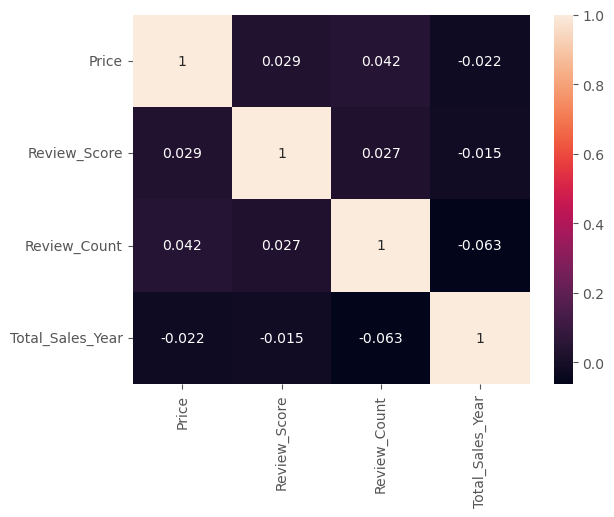

In [89]:
sns.heatmap(df_corr, annot=True)

C:\Users\zaize\AppData\Local\Temp\ipykernel_13012\990612539.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_velocity = df.groupby('Price_Tier')['Total_Sales_Year'].mean()


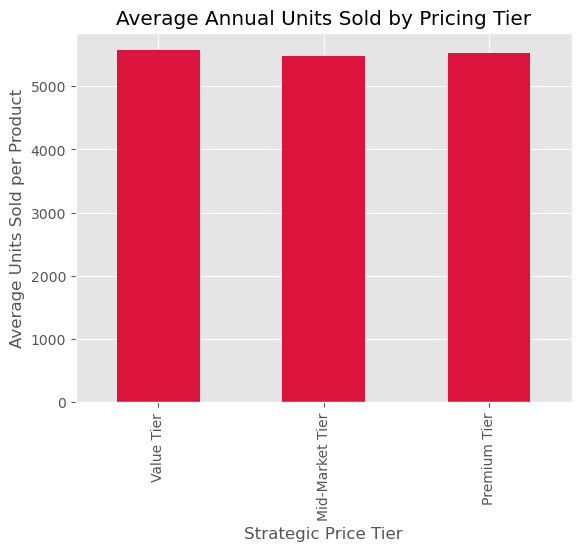

In [ ]:
# 5 Ask Questions
# What is the average transaction velocity (units sold) of premium products versus value-tier products?

# segment prices into 3 tiers
df['Price_Tier'] = pd.qcut(df['Price'], q=3, labels=['Value Tier', 'Mid-Market Tier', 'Premium Tier'])

# calculate average annual sales volume by each tier
tiers = df.groupby('Price_Tier')['Total_Sales_Year'].mean()

plt6 = tiers.plot(kind='bar', title='Average Annual Units Sold by Pricing Tier', color='crimson')
plt6.set_xlabel('Price Tier')
plt6.set_ylabel('Average Units Sold per Product')
plt.show()

In [ ]:
# Because price tiers were balanced, I shifted to analyze the ratio of consumer reviews  relative to the product price.

# calculate an engagement score per product row
df['Engagement_Index'] = df['Review_Count'] / df['Price']

# isolate top 10 highest-efficiency products
viral_products = df[['Product_Name', 'Category', 'Price', 'Review_Count', 'Engagement_Index']].sort_values(by='Engagement_Index', ascending=False).head(10)
viral_products

# these products have high sales volume and high review count, demonstrating the most viral products

,Product_Name,Category,Price,Review_Count,Engagement_Index
128,Product_129,Books,8.44,960,113.744076
205,Product_206,Books,9.55,848,88.795812
945,Product_946,Toys,10.44,695,66.570881
936,Product_937,Electronics,14.10,883,62.624113
563,Product_564,Electronics,12.20,749,61.393443
456,Product_457,Home & Kitchen,10.62,632,59.510358
898,Product_899,Clothing,11.44,664,58.041958
356,Product_357,Electronics,18.12,949,52.373068
312,Product_313,Toys,17.55,896,51.054131
371,Product_372,Home & Kitchen,14.02,646,46.077033


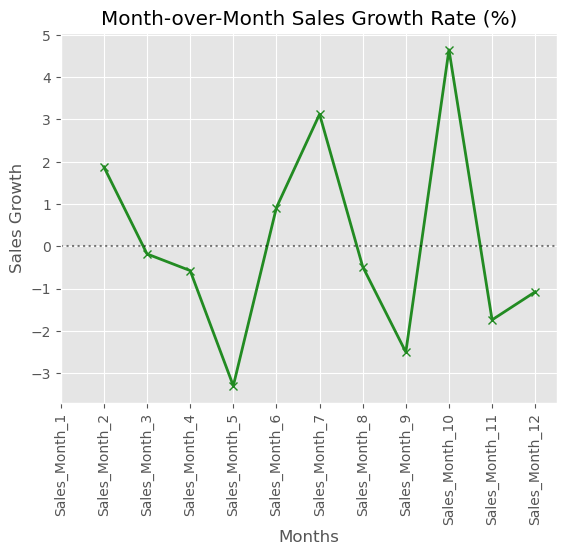

In [91]:
#Which specific month has the single biggest surge in transactions?
sales_columns = [f'Sales_Month_{i}' for i in range(1, 13)]
monthly_totals = df[sales_columns].sum()
monthly_growth = monthly_totals.pct_change() * 100

plt7 = monthly_growth.plot(kind='line', marker='x', title='Month-over-Month Sales Growth Rate (%)', color='forestgreen', linewidth=2)
plt7.set_xlabel('Months')
plt.xticks(ticks=np.arange(12), labels=sales_columns, rotation='vertical')
plt7.set_ylabel('Sales Growth')
plt7.axhline(0, color='black', linestyle=':', alpha=0.5)
plt.show()


Top 10 Most Efficent/Viral Product Listings:


,Product_Name,Category,Price,Review_Count,Engagement_Index
128,Product_129,Books,8.44,960,113.744076
205,Product_206,Books,9.55,848,88.795812
945,Product_946,Toys,10.44,695,66.570881
936,Product_937,Electronics,14.10,883,62.624113
563,Product_564,Electronics,12.20,749,61.393443
456,Product_457,Home & Kitchen,10.62,632,59.510358
898,Product_899,Clothing,11.44,664,58.041958
356,Product_357,Electronics,18.12,949,52.373068
312,Product_313,Toys,17.55,896,51.054131
371,Product_372,Home & Kitchen,14.02,646,46.077033
